In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Question 1

### A

In [3]:
#A.
df = pd.read_csv ('ForeignGifts_edu.csv')

### B

In [4]:
#B. 
print(df["Gift Type"].unique())

['Monetary Gift' 'Contract' 'Real Estate']


ADD DESCRIPTION HERE

### C

In [5]:

#a.
df.groupby("Country of Giftor").sum("Foreign Gift Amount").sort_values(by="Foreign Gift Amount", ascending=False).head(1)

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
Country of Giftor,,,,
QATAR,14133760,207860000,29707239,2706240869


The country that gives the most money in total is Qatar at $2,706,240,869.

In [13]:
#b.
df["Country of Giftor"].value_counts().head(1)

Country of Giftor
ENGLAND    3655
Name: count, dtype: int64

The country that initiates the most gifts by count is England.

In [14]:
#c.
df.groupby("Country of Giftor").mean("Foreign Gift Amount").sort_values(by="Foreign Gift Amount", ascending=False).head(1)

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
Country of Giftor,,,,
BERMUDA,18171.854701,265962.393162,42919.008547,7.688837e+06


The country that gives the largest gifts on average is Bermuda.

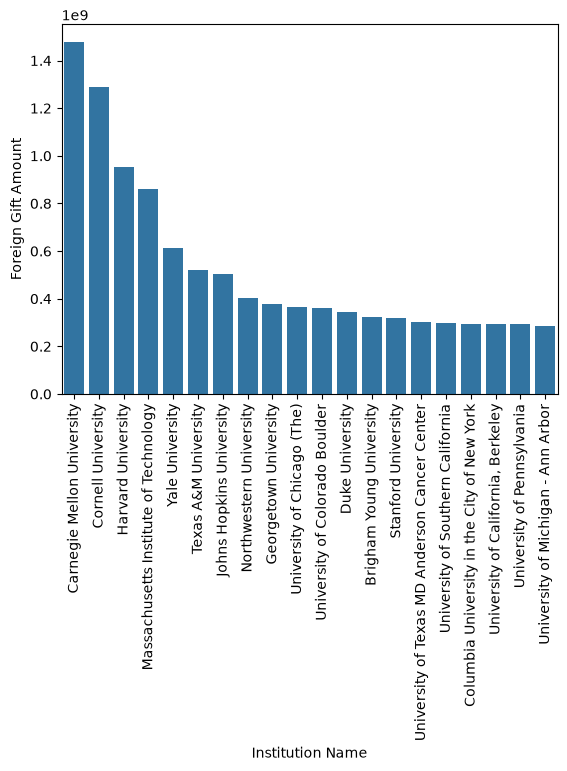

In [16]:
#d.
df_institution_giftamount = df.groupby("Institution Name").sum("Foreign Gift Amount").sort_values(by="Foreign Gift Amount", ascending=False).head(20)

sns.barplot(data = df_institution_giftamount, x="Institution Name", y = "Foreign Gift Amount")
plt.xticks(rotation=90)
plt.show()

Based on the bar chart above, Carnegie Melon University recieveed the most money in total.

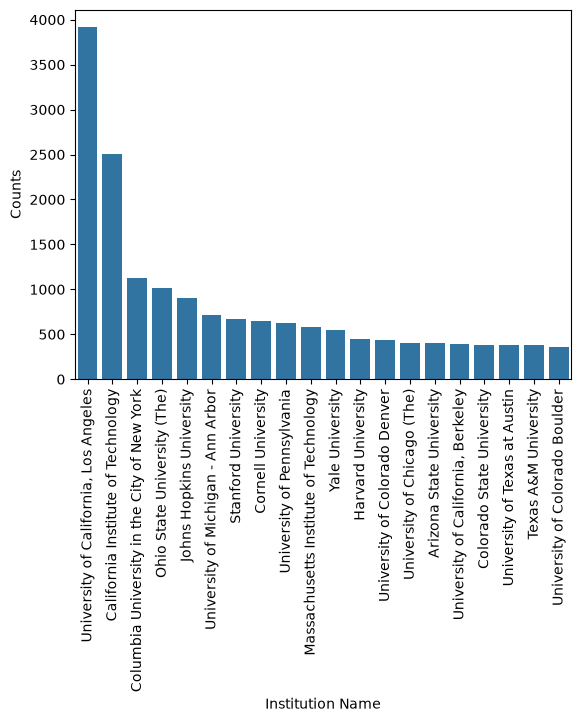

In [17]:
#e
df_institution_count = df["Institution Name"].value_counts().reset_index(name='Counts').head(20)

sns.barplot(data = df_institution_count, x="Institution Name", y = "Counts")
plt.xticks(rotation=90)
plt.show()

The bar chart above shows that University of Caalifornia, Los Angeles recieved the greatest number of gifts by count.

<Axes: xlabel='Foreign Gift Amount', ylabel='Count'>

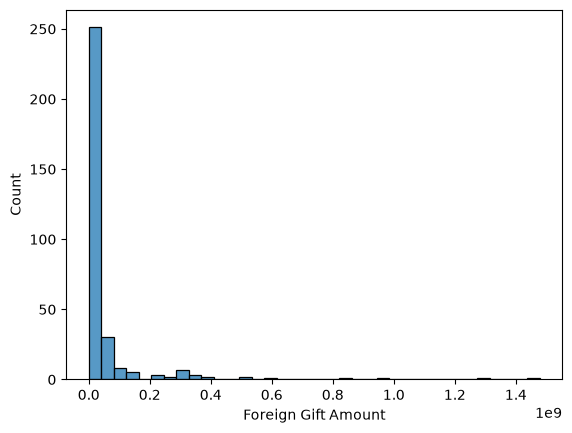

In [19]:
#f.
df_institution_giftamount2 = df.groupby("Institution Name").sum("Foreign Gift Amount")

sns.histplot(data = df_institution_giftamount2, x = "Foreign Gift Amount")

THIS ONE NEEDS WORK - not including median and mode rn

In [ ]:
#g.
pd.crosstab(df["Institution Name"], df["Country of Giftor"], values=df["Foreign Gift Amount"], aggfunc="sum").stack().sort_values(ascending = False).head(1)

Institution Name    Country of Giftor
Cornell University  QATAR                1.018473e+09
dtype: float64

This output above shows that the larget flow between a single coountry and a single institution is from QATAR to Cornell.

In [46]:
#h.
import plotly.graph_objects as go

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

The plot above shows that the top giftors to US academic institutions are Qatar, Bermuda, and United Arab Emirates.